# 2D Timoshenko Beam


In [1]:
# [collapse: code] Colab Setup (Install Dependencies)

# Only run this if we are in Google Colab
if 'google.colab' in str(get_ipython()):
    print("Installing dependencies using uv...")
    # Install uv if not available
    !pip install -q uv
    # Install system dependencies
    !apt-get install -qq gmsh
    # Use uv to install Python dependencies
    !uv pip install --system matplotlib meshio
    !uv pip install --system "git+https://github.com/smec-ethz/tatva-docs.git"
    print("Installation complete!")
    


This tutorial demonstrates how to implement a custom finite element in **Tatva**. We use a 2D Timoshenko beam as our example. You will learn how to go from a local energy density definition to a full nonlinear sparse solver using JAX and Tatva's differentiable engine.

Unlike [Euler-Bernoulli beams](euler_bernoulli_2d_beam.ipynb), the **Timoshenko model** accounts for shear deformation. This is essential for "thick" beams where the cross-section does not remain perfectly perpendicular to the neutral axis.

The kinematic state is defined by:

* $w(x)$: Transverse displacement.
* $\theta(x)$: Section rotation.

The total strain energy $\Psi$ is the integral of axial, shear, and bending densities:

$$\Psi = \int_0^L \left( \Psi_\text{axial} + \Psi_\text{shear} + \Psi_\text{bending} \right) ds$$

## Setup and Imports

We start by configuring JAX. Finite Element Method (FEM) calculations usually require double precision (`float64`) to ensure the stiffness matrix is accurate. We also import `tatva` components to handle the mesh and operator logic.

In [2]:
import jax

jax.config.update("jax_enable_x64", True)  # use double-precision

import time
from functools import partial
from typing import NamedTuple

import equinox as eqx
import jax.experimental.sparse as jsp
import jax.numpy as jnp
import numpy as np
from jax import Array
from jax_autovmap import autovmap
from tatva import Mesh, Operator, element, sparse

## Mesh Generation

We create a simple 1D line mesh embedded in 2D space. The `Mesh` object in `tatva` holds two key pieces of data:

-  **Coordinates**: Where the nodes are located in space.
-  **Connectivity**: Which nodes connect to form an element.

In [3]:
# [collapse: code] Mesh creation function


def create_beam_structure(nb_elem, length=1):
    xi = jnp.linspace(0, length, nb_elem + 1)
    yi = jnp.zeros_like(xi)
    coordinates = jnp.vstack((xi.flatten(), yi.flatten())).T
    connectivity = list()
    for i in range(nb_elem):
        connectivity.append([i, i + 1])
    connectivity = jnp.unique(jnp.array(connectivity), axis=0)

    mesh = Mesh(coords=coordinates, elements=connectivity)

    return mesh

In [4]:
L = 1  # Total length of the beam
nb_elem = 20

mesh = create_beam_structure(nb_elem=nb_elem, length=L)
n_nodes = mesh.coords.shape[0]
nb_nodes_per_cell = mesh.elements.shape[1]
nb_dofs_per_node = 3
n_dofs = n_nodes * nb_dofs_per_node

## Defining the Custom Timoshenko Element

In Tatva, custom elements inherit from `element.Element`. You must define the shape functions and the mapping from natural coordinates ($\xi \in [-1, 1]$) to
physical space. For a 2nd-order beam in 2D space, we define a `Line2In3D` class  (which also works for 2D). This class handles the **Jacobian** calculations necessary for arc-length integration.


!!! info "Defining Custom Element"

    To define a custom element inherit from `tatva.element.Element` and reimplement the following functions:

    - `shape_function`
    - `shape_function_derivative`
    - `gradient` which is used by `Operator.grad` to compute the gradient of physical   field

    Unlike [Euler-Bernoulli beams](euler_bernoulli_2d_beam.ipynb), we donot implement `interpolate` function because here the Line element only requires shape functions and nodal values to interpolate.

In [10]:
class Line2In3D(element.Element):
    """
    A 2-node linear element embedded in 2D/3D space.
    Should be used for Timoshenko beam formulations.
    """


    def _default_quadrature(self):
        # 1-point Gauss quadrature for line element
        quad_points = jnp.array([0.0])  # Natural coordinate at the center
        quad_weights = jnp.array([2.0])  # Weight for the quadrature point
        return quad_points, quad_weights
        

    def shape_function(self, xi: Array) -> Array:
        return jnp.array([0.5 * (1.0 - xi), 0.5 * (1.0 + xi)])

    def shape_function_derivative(self, xi: Array) -> Array:
        return jnp.array([-0.5, 0.5])

    def get_jacobian(self, xi: Array, nodal_coords: Array) -> tuple[Array, Array]:
        """
        Assumes nodal_coords is of shape (2, 3) for the two nodes in 3D space.
        Args:
            xi: Natural coordinate (-1 to 1)
            nodal_coords: Array of shape (2, 3) containing the coordinates of the two nodes.

        Returns:
            J_vec: The tangent vector (unnormalized) dx/dxi
            detJ: The scaling factor (ds/dxi) = norm(J_vec)
        """
        dN_dxi = self.shape_function_derivative(xi)
        J_vec = dN_dxi @ nodal_coords  # Shape: (3,) or (2, )
        detJ = jnp.linalg.norm(J_vec)
        return J_vec, detJ

    def gradient(self, xi: Array, nodal_values: Array, nodal_coords: Array) -> Array:
        """
        Returns the derivative of the field w.r.t physical arc length s.

        If nodal_values is (2, 3) [Displacement], returns (3,) vector [du/ds, dv/ds, dw/ds]
        If nodal_values is (2, 1) [Scalar], returns (1,) scalar [dT/ds]

        Args:
            xi: Natural coordinate (-1 to 1)
            nodal_values: Array of shape (2, dofs_per_node) containing the values
            nodal_coords: Array of shape (2, 3) containing the coordinates of the two nodes.
        Returns:
            Array of shape (dofs_per_node,) containing the gradient of the field w.r.t physical arc length s.
        """
        J_vec, detJ = self.get_jacobian(xi, nodal_coords)
        dN_dxi = self.shape_function_derivative(xi)
        du_dxi = dN_dxi @ nodal_values
        du_ds = du_dxi / detJ

        return du_ds


## Strain Energy Density

We define the material behavior. For a linear elastic Timoshenko beam, the potential energy density $\Psi$ depends on the axial strain $\varepsilon$, shear strain $\gamma$ and the curvature $\chi$:

$$\Psi(\varepsilon, \kappa) = \frac{1}{2} EA \varepsilon^2 + \frac{1}{2} EI \chi^2 + \frac{1}{2}G\kappa A \gamma^2$$

In the Timoshenko beam model, we define the physics by relating the displacement gradients and rotations to the beam's local orientation. In the implementation, `du_ds` is the derivative of the displacement vector with respect to the arc length $s$, and `dtheta_ds` represents the curvature.

### Axial Strain ($\epsilon$)
The axial strain measures the stretching or compression along the beam's neutral axis. This is calculated by projecting the displacement gradient vector onto the unit **tangent** vector of the beam. 

$$\epsilon = \frac{du}{ds} \cdot \mathbf{t}$$

If the displacement gradient is parallel to the tangent, the beam is stretching. If it is perpendicular, there is no axial deformation.


### Shear Strain ($\gamma$)
Timoshenko theory assumes that shear strain is the difference between the **geometric slope** of the neutral axis and the **rotation** of the cross-section.

* **Geometric Slope**: We compute the component of the displacement gradient perpendicular to the beam by projecting `du_ds` onto the **normal** vector (the tangent rotated by 90°).
* **Shear Deformation**: In Euler-Bernoulli theory, the cross-section remains perpendicular to the axis, so the slope and rotation are equal. In this model, any difference between the slope and the rotation $\theta$ represents shear.

$$\gamma = \left( \frac{du}{ds} \cdot \mathbf{n} \right) - \theta$$


### Bending Curvature
Curvature measures how the rotation changes along the length of the beam. This is the primary driver for bending energy.  Unlike simpler beam models where curvature is the second derivative of displacement, here it is the first derivative of the independent rotation field $\theta$:

$$\chi = \frac{d\theta}{ds}$$

!!! tip
    
    We use the `@autovmap` decorator. This tells JAX to automatically vectorize this function, applying it efficiently to every integration point in the mesh at once.

In [11]:
@autovmap(du_ds=1, dtheta_ds=1, theta=1, tangent=1, E=0, A=0, I=0, G=0, J=0)
def timoshenko_density(du_ds, dtheta_ds, theta, tangent, E, A, I, G, J):
    """
    Computes strain energy density at a single integration point.

    Args:
        du_ds: (3,) Derivative of displacement w.r.t arc length s
        dtheta_ds: (3,) Derivative of rotation w.r.t arc length s
        theta: (3,) Rotation vector value
        tangent: (3,) Unit tangent vector of the beam
        E, A, I, G, J: Scalar stiffness properties

    Returns:
        Scalar energy density
    """

    epsilon = jnp.dot(du_ds, tangent)

    normal = jnp.array([-tangent[1], tangent[0]])

    geometric_slope = jnp.dot(du_ds, normal)
    gamma = geometric_slope - theta

    w_axial = 0.5 * E * A * epsilon**2
    w_shear = 0.5 * G * kappa * A * jnp.dot(gamma, gamma)
    w_bend = 0.5 * E * I * jnp.dot(dtheta_ds, dtheta_ds)

    return w_axial + w_shear + w_bend

## Problem Setup: Material and Boundary Conditions

We define the geometric and material properties:
* $E$: Young's Modulus
* $A$: Cross-sectional area
* $I$: Second moment of area

We also define the boundary conditions. We find the node indices for the left and right ends of the beam. We clamp the left end (fixing displacements and rotation) and apply a load to the right end.

In [12]:
# material and geometrical parameters
E = 500
h = 1
A = h**2
I = h * h**3 / 12

G = E / 10.
kappa = 5 / 6  # shear correction coefficient (for rectangular cross section )


class Material(NamedTuple):
    E: float
    A: float
    I: float
    G: float
    kappa: float


mat = Material(E=E, A=A, I=I, G=G, kappa=kappa)

In [13]:
x_max = jnp.max(mesh.coords[:, 0])
x_min = jnp.min(mesh.coords[:, 0])
y_max = jnp.max(mesh.coords[:, 1])
y_min = jnp.min(mesh.coords[:, 1])

left_nodes = jnp.where(jnp.isclose(mesh.coords[:, 0], x_min, atol=1e-6))[0]

right_nodes = jnp.where(jnp.isclose(mesh.coords[:, 0], x_max, atol=1e-6))[0]


fixed_dofs = jnp.concatenate(
    [
        left_nodes * nb_dofs_per_node,
        left_nodes * nb_dofs_per_node + 1,
        left_nodes * nb_dofs_per_node + 2,
    ]
)

applied_dofs = jnp.array(right_nodes * nb_dofs_per_node + 1)

free_dofs = jnp.setdiff1d(jnp.arange(n_dofs), fixed_dofs)

## The `Operator` and Energy Minimization

We initialize the `Operator` with our mesh and custom element. This binds the geometry to the physics. We then define the `total_energy` function. This function integrates the energy density over the entire domain.

* **Input**: Global displacement vector.
* **Output**: Total scalar energy.

Because `tatva` is a differentiable engine, we can compute the internal force vector simply by taking the gradient of this energy function: $\boldsymbol{f}_{int} = \nabla \Psi$.

In [14]:
beam_element = Line2In3D()
op = Operator(mesh=mesh, element=beam_element)

### Precomputing Tangents for Field Projections

In Tatva, we define physics in a local coordinate system. However, the mesh exists in global physical space for example, the axial strain is along the beam and shear strain normal. We precompute unit tangents to project global gradients into the local axial and normal directions of the beam.

- **Axial projection**: We dot the gradient with the tangent to find stretching.
- **Normal projection**: We dot the gradient with the normal vector (the tangent rotated by 90°) to find the geometric slope.



Our implement custom element ha `get_jacobian` method that calculates how the physical coordinates $\mathbf{x}$ change relative to the natural coordinates $\xi$. This derivative is a vector that points along the beam axis.

$$\mathbf{J} = \frac{d\mathbf{x}}{d\xi}$$

We normalize the Jacobian vector by its magnitude (`detJ`) to get a unit tangent vector $\mathbf{t}$. We use `op.map` to perform this calculation efficiently across the entire mesh.

In [15]:
J_vecs, detJs = op.map(beam_element.get_jacobian)(mesh.coords)
    
tangents = J_vecs / detJs[..., None]

## Defining the total energy

In [16]:
@jax.jit
def _total_energy_timoshenko(z_flat: Array, tangents: Array) -> Array:
    """
    Computes total Timoshenko beam energy.
    Args:
        z_flat: (n_nodes * 3,) Flattened displacement and rotation vector (ux1, uy1, theta1, ...)
        tangents: (n_elements, 3) Unit tangent vectors for each element
    Returns:
        Scalar total energy of the beam
    """

    z = z_flat.reshape(-1, 3)  # ux, uy, theta

    u = z[:, [0, 1]]  # ux, uy
    theta = z[:, [2]]  # theta

    du_ds = op.grad(u)
    dtheta_ds = op.grad(theta)

    theta_quad = op.eval(theta)

    density = timoshenko_density(
        du_ds, dtheta_ds, theta_quad, tangents, mat.E, mat.A, mat.I, mat.G, mat.kappa
    )

    return op.integrate(density)

total_energy_timoshenko = eqx.Partial(_total_energy_timoshenko, tangents=tangents)

### Applying Boundary Conditions to the Energy Functional

To solve the system, we must distinguish between **free DOFs** (nodes that can move) and **fixed DOFs** (nodes with prescribed displacements). We apply these constraints directly within the energy functional. The total energy of the system depends on the full displacement vector $u_{full}$. However, the optimizer only needs to find the values for the free DOFs. We create a wrapper function that takes only the unknown values (`u_free`) and the prescribed values (`applied_disp`) as inputs.

Inside the wrapper, we reconstruct the complete displacement vector. We use JAX's functional array updates (`at[].set()`) to ensure the operation is compatible with automatic differentiation.


In [17]:
@eqx.filter_jit
def total_energy_timoshenko_free(u_free, applied_disp):
    u_full = jnp.zeros(n_dofs).at[free_dofs].set(u_free)
    u_full = u_full.at[fixed_dofs].set(applied_disp)
    return total_energy_timoshenko(u_full)


compute_internal_free = jax.jacrev(total_energy_timoshenko_free)

## Sparse Solver

To solve the system, we minimize the total potential energy. We use a Newton-Raphson scheme, which is robust for both linear and nonlinear problems.

1.  **Sparsity**: We compute the sparsity pattern of the Hessian (stiffness matrix) and color the graph. This allows AD to compute the matrix efficiently.
2.  **Solver Loop**:
    
    * Compute Residual: $\boldsymbol{r} = \boldsymbol{f}_{ext} - \boldsymbol{f}_{int}$
    * Compute Stiffness: $K = \nabla^2 \Psi$ 
    * Solve linear system: $K \Delta \boldsymbol{u} = -\boldsymbol{r}$
    * Update solution

In [18]:
sparsity_pattern_csr = sparse.create_sparsity_pattern(
    mesh, n_dofs_per_node=nb_dofs_per_node
)
reduced_sparsity_pattern_csr = sparse.reduce_sparsity_pattern(sparsity_pattern_csr, free_dofs)
colored_matrix = sparse.ColoredMatrix.from_csr(reduced_sparsity_pattern_csr)

In [19]:
def fn(u, fext, applied_disp):
    fint = compute_internal_free(u, applied_disp)
    return fext - fint


### Sparse solver with implicit condensation

In [20]:
u = jnp.zeros(n_dofs)
fext = jnp.zeros(n_dofs)

nsteps = 20
P = -1.0
applied_loading = jnp.linspace(0, P, num=nsteps)

dumped_nodes = jnp.zeros((nsteps, n_nodes * (nb_dofs_per_node - 1)))

dumped_loads = jnp.zeros(nsteps)

errors = jnp.zeros(nsteps)

u_free = u.at[free_dofs].get()

fn_partial = jax.jit(
    partial(fn, fext=fext.at[free_dofs].get(), applied_disp=jnp.zeros(len(fixed_dofs)))
)
start_time = time.time()
hessian_fn = sparse.jacfwd(
    fn=fn,
    colored_matrix=colored_matrix,
    color_batch_size=len(jnp.unique(colored_matrix.colors)) + 1,
)

print(f"Time to compute Hessian: {time.time() - start_time:.2f} seconds")


max_iter = 20
for step, load in enumerate(applied_loading):
    fext = fext.at[applied_dofs].set(load)
    fext_free = fext.at[free_dofs].get()
    fn_partial = eqx.Partial(
        fn, fext=fext_free, applied_disp=jnp.zeros(len(fixed_dofs))
    )

    hessian_partial = eqx.Partial(
        hessian_fn, fext=fext_free, applied_disp=jnp.zeros(len(fixed_dofs))
    )

    residual = fn_partial(u_free)
    K_sparse = hessian_partial(u_free)

    du = jnp.zeros(len(free_dofs))
    rnorm = jnp.linalg.norm(residual)
    iiter = 0

    while rnorm > 1e-8 and iiter < max_iter:
        du = du + jsp.linalg.spsolve(
            K_sparse.data,
            indices=K_sparse.indices,
            indptr=K_sparse.indptr,
            b=-residual,
        )

        u_curr = u_free + du
        residual = fn_partial(u_curr)

        K_sparse = hessian_partial(u_curr)

        rnorm = jnp.linalg.norm(residual)

        iiter += 1

    u_free = u_free + du
    u = u.at[free_dofs].set(u_free)

    new_nodes = mesh.coords + u.reshape((n_nodes, nb_dofs_per_node))[:, :2]
    dumped_nodes = dumped_nodes.at[step].set(new_nodes.reshape(-1))
    dumped_loads = dumped_loads.at[step].set(load)
    errors = errors.at[step].set(rnorm)

    print(load, rnorm)

Time to compute Hessian: 1.29 seconds
0.0 0.0
-0.05263157894736842 8.661987206383461e-16
-0.10526315789473684 1.495195790406089e-15
-0.15789473684210525 1.9501771809829737e-15
-0.21052631578947367 2.096276232171222e-15
-0.2631578947368421 2.8107152550925102e-15
-0.3157894736842105 2.554050876383185e-15
-0.3684210526315789 2.9002397657007396e-15
-0.42105263157894735 4.221530041105687e-15
-0.47368421052631576 4.253123118534668e-15
-0.5263157894736842 5.097204439630478e-15
-0.5789473684210527 5.974456405152619e-15
-0.631578947368421 4.480795775389153e-15
-0.6842105263157894 6.6941376356131784e-15
-0.7368421052631579 6.25163919767827e-15
-0.7894736842105263 7.819505394566142e-15
-0.8421052631578947 5.8713540051312226e-15
-0.894736842105263 7.03390048331369e-15
-0.9473684210526315 7.164729691461396e-15
-1.0 6.623486819437671e-15


## Validation

We compare the Finite Element results against the analytical solution for a cantilever beam with a point load $P$ at the tip.

**Analytical Solutions:**

* Transverse displacement 

$$
w(x) = \underbrace{\frac{P}{6EI}(3Lx^2 - x^3)}_{\text{Bending}} + \underbrace{\frac{Px}{\kappa AG}}_{\text{Shear}}
$$

* Rotation 

$$\theta(x) = \frac{P}{2EI}(2Lx - x^2)$$

The plots below show that our custom `tatva` element matches the theoretical values.

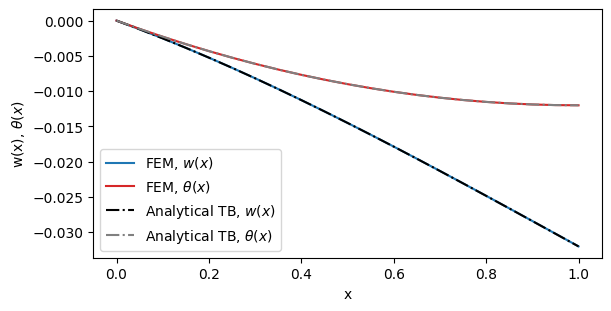

In [21]:
# [collapse: code] Plotting the results

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 3), constrained_layout=True)
ax = plt.axes()

ax.plot(
    mesh.coords[:, 0],
    u.reshape((n_nodes, nb_dofs_per_node))[:, 1],
    color="tab:blue",
    label="FEM, $w(x)$",
)
ax.plot(
    mesh.coords[:, 0],
    u.reshape((n_nodes, nb_dofs_per_node))[:, 2],
    color="tab:red",
    label="FEM, $\\theta(x)$",
)

ax.plot(
    mesh.coords[:, 0],
    P * (3 * L * mesh.coords[:, 0] ** 2 - mesh.coords[:, 0] ** 3) / (6 * E * I)
    + (P * mesh.coords[:, 0]) / (kappa * A * G),
    color="k",
    ls="dashdot",
    label="Analytical TB, $w(x)$",
)
ax.plot(
    mesh.coords[:, 0],
    P * (2 * L * mesh.coords[:, 0] - mesh.coords[:, 0] ** 2) / (2 * E * I),
    color="gray",
    ls="dashdot",
    label="Analytical TB, $\\theta(x)$",
)


# ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("w(x), $\\theta(x)$")
ax.legend()
plt.show()